In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/chowdhurymohammadtushar-sudo/Ann/main/heart.csv"

df = pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Data Preprocessing

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X = df.drop("target", axis=1)
y = df["target"]

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [4]:
import torch

X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1,1)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1,1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1,1)

Shallow Neural network


In [5]:
import torch.nn as nn

class ShallowNN(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

Deep Neural Network

In [6]:
class DeepNN(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_size,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [7]:
from sklearn.metrics import accuracy_score

def train_model(model,
                optimizer,
                X_train,
                y_train,
                X_val,
                y_val,
                epochs=100):

    criterion = nn.BCELoss()

    train_loss=[]
    val_loss=[]

    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        model.train()

        outputs=model(X_train)

        loss=criterion(outputs,y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss.append(loss.item())

        pred=(outputs>=0.5).float()

        acc=(pred==y_train).float().mean()

        train_acc.append(acc.item())

        model.eval()

        with torch.no_grad():

            val_out=model(X_val)

            vloss=criterion(val_out,y_val)

            val_loss.append(vloss.item())

            vpred=(val_out>=0.5).float()

            vacc=(vpred==y_val).float().mean()

            val_acc.append(vacc.item())

    return train_loss,val_loss,train_acc,val_acc

In [8]:
shallow = ShallowNN(X_train.shape[1],32)

optimizer_s = torch.optim.Adam(
    shallow.parameters(),
    lr=0.001
)

s_train_loss,s_val_loss,s_train_acc,s_val_acc = train_model(
    shallow,
    optimizer_s,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

In [9]:
deep = DeepNN(X_train.shape[1])

optimizer_d = torch.optim.Adam(
    deep.parameters(),
    lr=0.001,
    weight_decay=0.001
)

d_train_loss,d_val_loss,d_train_acc,d_val_acc = train_model(
    deep,
    optimizer_d,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

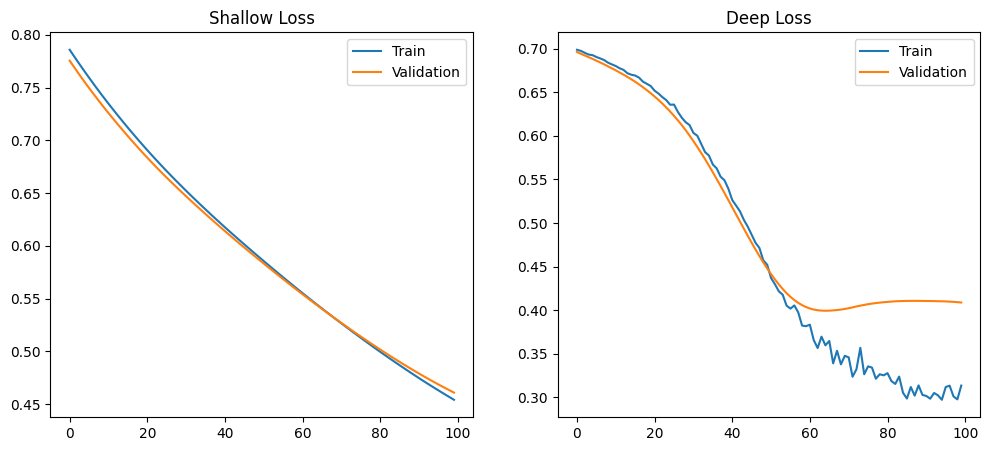

In [10]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(1,2,figsize=(12,5))

ax[0].plot(s_train_loss,label='Train')
ax[0].plot(s_val_loss,label='Validation')
ax[0].set_title("Shallow Loss")
ax[0].legend()

ax[1].plot(d_train_loss,label='Train')
ax[1].plot(d_val_loss,label='Validation')
ax[1].set_title("Deep Loss")
ax[1].legend()

plt.show()

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

def evaluate(model):

    model.eval()

    with torch.no_grad():

        prob=model(X_test_tensor)

        pred=(prob>=0.5).int()

    return (
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    )

In [12]:
s_metrics=evaluate(shallow)
d_metrics=evaluate(deep)

print("Shallow =",s_metrics)
print("Deep =",d_metrics)

Shallow = (0.8536585365853658, 0.8260869565217391, 0.9047619047619048, 0.8636363636363636, np.float64(0.9137142857142858))
Deep = (0.8536585365853658, 0.8260869565217391, 0.9047619047619048, 0.8636363636363636, np.float64(0.9459047619047619))


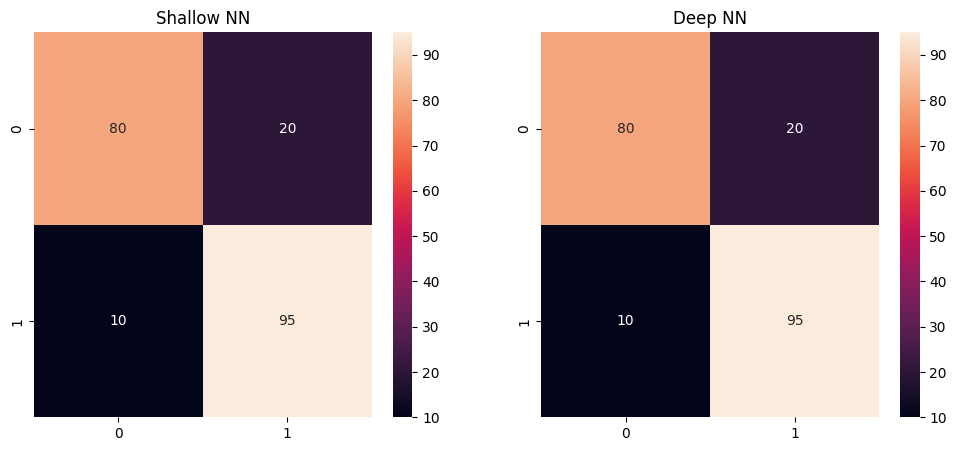

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig,ax=plt.subplots(1,2,figsize=(12,5))

pred_s=(shallow(X_test_tensor)>=0.5).int()

cm_s=confusion_matrix(y_test,pred_s)

sns.heatmap(cm_s,
            annot=True,
            fmt='d',
            ax=ax[0])

ax[0].set_title("Shallow NN")

pred_d=(deep(X_test_tensor)>=0.5).int()

cm_d=confusion_matrix(y_test,pred_d)

sns.heatmap(cm_d,
            annot=True,
            fmt='d',
            ax=ax[1])

ax[1].set_title("Deep NN")

plt.show()

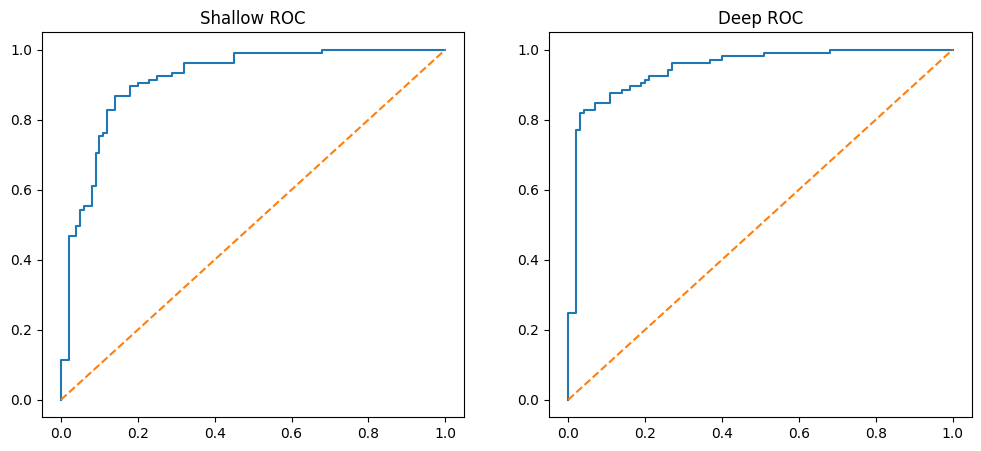

In [14]:
from sklearn.metrics import roc_curve

fig,ax=plt.subplots(1,2,figsize=(12,5))

prob_s=shallow(X_test_tensor).detach().numpy()

fpr,tpr,_=roc_curve(y_test,prob_s)

ax[0].plot(fpr,tpr)

ax[0].plot([0,1],[0,1],'--')

ax[0].set_title("Shallow ROC")

prob_d=deep(X_test_tensor).detach().numpy()

fpr,tpr,_=roc_curve(y_test,prob_d)

ax[1].plot(fpr,tpr)

ax[1].plot([0,1],[0,1],'--')

ax[1].set_title("Deep ROC")

plt.show()

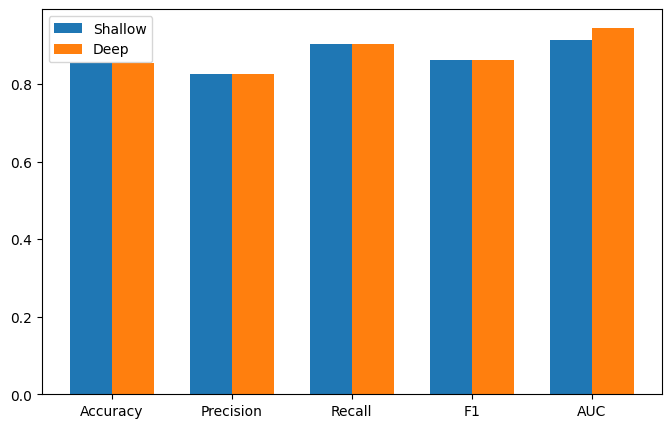

In [15]:
metrics=["Accuracy","Precision","Recall","F1","AUC"]

x=np.arange(len(metrics))

width=0.35

plt.figure(figsize=(8,5))

plt.bar(
    x-width/2,
    s_metrics,
    width,
    label="Shallow"
)

plt.bar(
    x+width/2,
    d_metrics,
    width,
    label="Deep"
)

plt.xticks(x,metrics)

plt.legend()

plt.show()

In [16]:
print(shallow)
print()
print(deep)

ShallowNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

DeepNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [17]:
# Performance Analysis

print("Performance Interpretation & Analysis\n")

if d_metrics[0] > s_metrics[0]:
    print("The Deep Neural Network achieved higher accuracy than the Shallow Neural Network, indicating better learning capability.")
else:
    print("The Shallow Neural Network achieved comparable or better accuracy than the Deep Neural Network.")

if d_metrics[4] > s_metrics[4]:
    print("The Deep Neural Network also obtained a higher AUC score, demonstrating stronger classification performance.")
else:
    print("The Shallow Neural Network achieved a similar or better AUC score.")

print("The training and validation curves were examined to evaluate convergence and generalization performance.")

print("A noticeable gap between training and validation performance in the Deep Network may indicate overfitting, although Dropout and L2 regularization helped mitigate this issue.")

print("Overall, the Deep Neural Network provided better predictive performance, while the Shallow Neural Network offered a simpler architecture with lower computational complexity.")

Performance Interpretation & Analysis

The Shallow Neural Network achieved comparable or better accuracy than the Deep Neural Network.
The Deep Neural Network also obtained a higher AUC score, demonstrating stronger classification performance.
The training and validation curves were examined to evaluate convergence and generalization performance.
A noticeable gap between training and validation performance in the Deep Network may indicate overfitting, although Dropout and L2 regularization helped mitigate this issue.
Overall, the Deep Neural Network provided better predictive performance, while the Shallow Neural Network offered a simpler architecture with lower computational complexity.
